# Machine Learning Model Development

This notebook continues from the exploratory data analysis (EDA) performed in `01_Data_Analysis.ipynb`.

The objective is to build and compare multiple machine learning models for predicting whether a customer will subscribe to a bank term deposit.

# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

The objective of this project is to predict whether a customer would subscribe to bank term deposit based on demographic information, previous campaign interactions and financial attributes.

## Load Dataset

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [7]:
df =  pd.read_csv(r"C:\Users\ATHAR\Downloads\pwskills\Internship Project\Bank Marketing Analysis\bankmarketing.csv")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
df.shape

(41188, 21)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [10]:
# Check for missing values and data types
df.isnull().sum()


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(12)

In [12]:
# Summary statistics
df.describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [13]:
# Traget variable
df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [14]:
print(df['y'].value_counts(normalize=True) * 100)

# highly imbalance data showing 88.73 % No And 11.26% Yes


y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


In [15]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [16]:
# Renaming the Target y to subscribe
df = df.rename(columns={'y':'Subscribe'})
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,Subscribe
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [17]:
# replacing the column and captalize the first letter
# df = df.rename(columns=lambda x: x.replace('.', '_').capitalize())
df = df.rename(columns=lambda x: x.lower().replace('.', '_'))

In [18]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,subscribe
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [19]:
# numerical column
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(list(num_cols))

Numerical Columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']


In [20]:
# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:")
print(list(cat_cols))

Categorical Columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'subscribe']


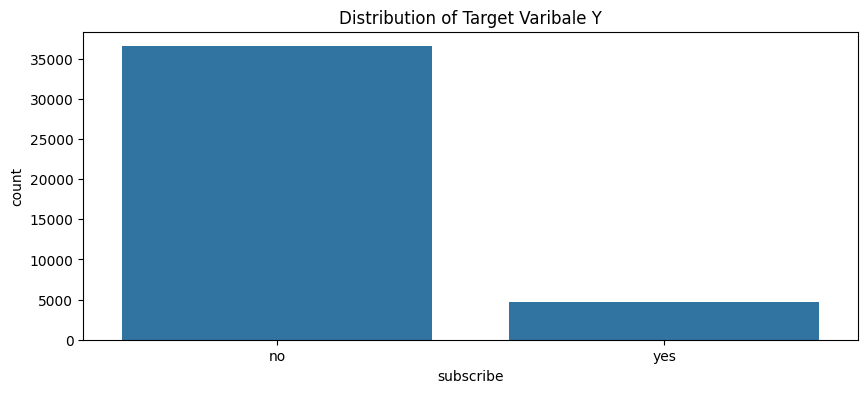

In [21]:
# Univarite Analysis
plt.figure(figsize=(10,4))
sns.countplot(x = 'subscribe', data= df)
plt.title("Distribution of Target Varibale Y")
plt.show()

## Customer Demographics Analysis

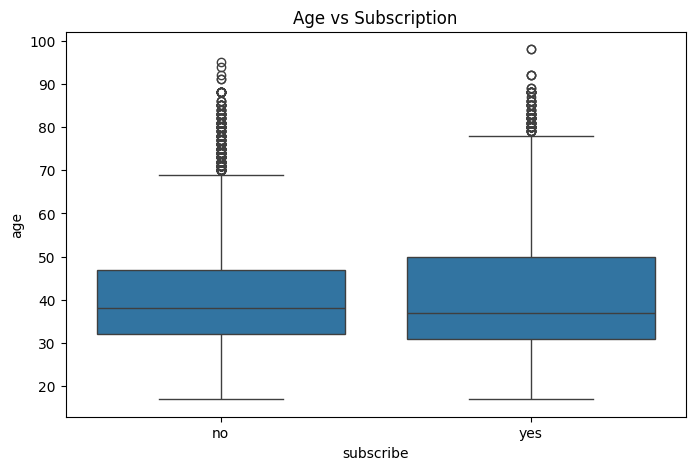

In [22]:
# Age distribution

plt.figure(figsize=(8,5))
sns.boxplot(x='subscribe', y='age', data=df)
plt.title('Age vs Subscription')
plt.show()


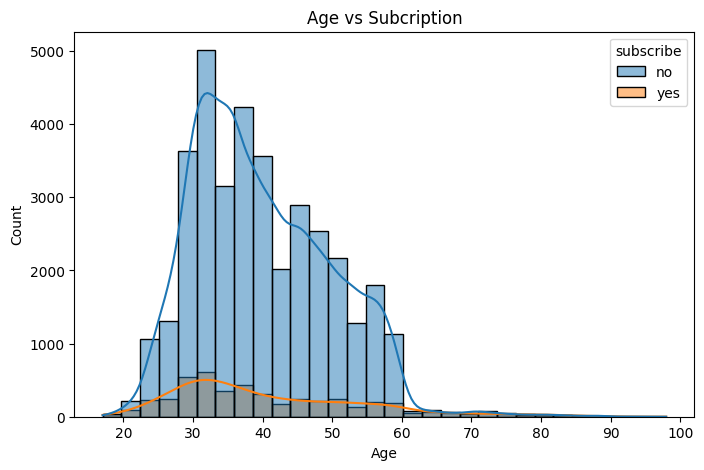

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(x ="age",bins=30, data = df, hue= 'subscribe', kde= True)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age vs Subcription")
plt.show()

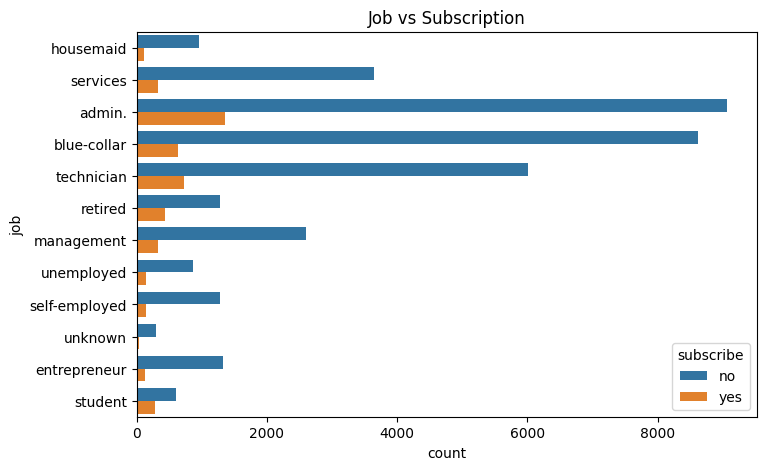

In [24]:
# Job distribution

plt.figure(figsize=(8,5))
sns.countplot(y='job',hue= 'subscribe', data=df)
plt.title('Job vs Subscription')
plt.show()


In [25]:
# Job Subscription Rate

job_sub = pd.crosstab(df['job'], df['subscribe'], normalize='index') * 100
job_sub.sort_values(by='yes', ascending=False)

subscribe,no,yes
job,,
student,68.571429,31.428571
retired,74.767442,25.232558
unemployed,85.798817,14.201183
admin.,87.027442,12.972558
management,88.782490,11.217510
unknown,88.787879,11.212121
technician,89.173958,10.826042
self-employed,89.514426,10.485574
housemaid,90.000000,10.000000


## Campaign Effectiveness

In [28]:
# Contact method analysis

campaign_sub = pd.crosstab(df['campaign'], df['subscribe'], normalize='index') * 100
campaign_sub.sort_values(by='yes', ascending=False).head(15)


subscribe,no,yes
campaign,,
1,86.962929,13.037071
2,88.543046,11.456954
3,89.252949,10.747051
4,90.607318,9.392682
6,92.339122,7.660878
5,92.495310,7.504690
17,93.103448,6.896552
11,93.220339,6.779661
23,93.750000,6.250000


In [29]:
# sns.boxplot(x='Subscribe', y='Campaign', data=df)
# plt.title('Campaign Contacts vs Subscription')
# plt.show()

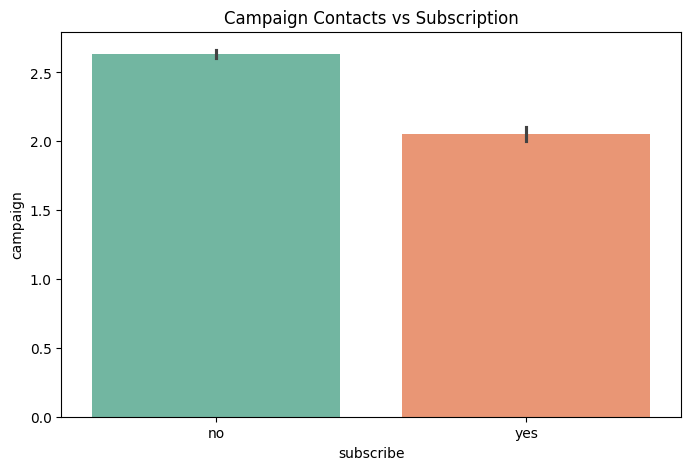

In [30]:
plt.figure(figsize=(8,5))
sns.barplot(x='subscribe', y='campaign', data=df, palette='Set2')
plt.title('Campaign Contacts vs Subscription')
plt.show()

In [31]:
# Number of contacts vs deposit subscription

# month-wise vs subscription
month_sub = pd.crosstab(df['month'], df['subscribe'], normalize='index') * 100
month_sub.sort_values(by='yes', ascending=False)


subscribe,no,yes
month,,
mar,49.450549,50.549451
dec,51.098901,48.901099
sep,55.087719,44.912281
oct,56.128134,43.871866
apr,79.521277,20.478723
aug,89.397863,10.602137
jun,89.488530,10.511470
nov,89.856133,10.143867
jul,90.953443,9.046557


## Correlation Heatmap

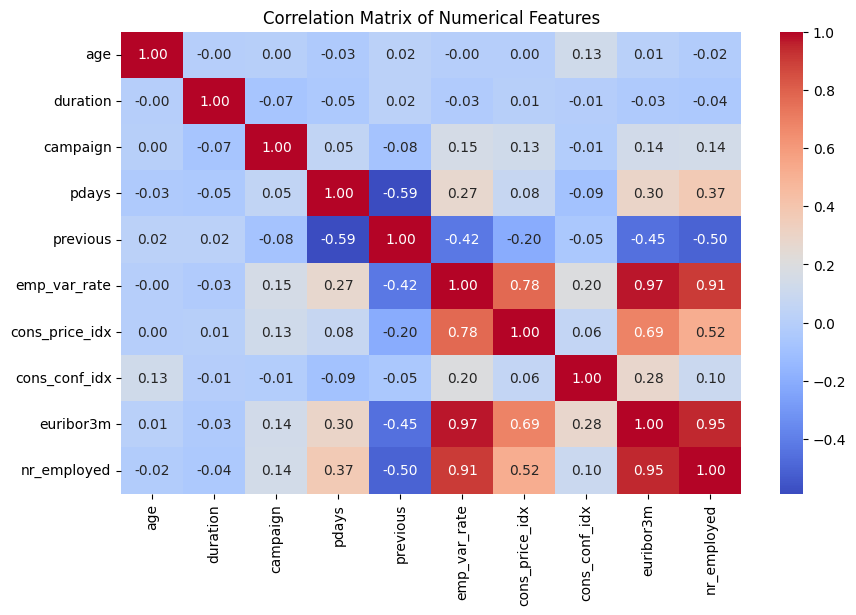

In [32]:
# Correlation of numerical variables

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()




In [33]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['subscribe'] = le.fit_transform(df['subscribe'])

In [34]:
# Seperate x and y
x = df.drop(['subscribe', 'duration'], axis=1)
y = df['subscribe']

In [35]:
cat_cols = x.select_dtypes(include='object').columns

num_cols = x.select_dtypes(
    include=['int64','float64']
).columns

In [36]:
print(len(cat_cols))
print(len(num_cols))

10
9


In [37]:
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6


In [38]:
y

0        0
1        0
2        0
3        0
4        0
        ..
41183    1
41184    0
41185    0
41186    1
41187    0
Name: subscribe, Length: 41188, dtype: int64

In [39]:
# Make pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [40]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((32950, 19), (8238, 19), (32950,), (8238,))

In [41]:
num_cols

Index(['age', 'campaign', 'pdays', 'previous', 'emp_var_rate',
       'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed'],
      dtype='object')

In [42]:
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

# Create One Common Pipeline

In [43]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Define Model

In [44]:
models = {
    'Logistic Regression' :LogisticRegression(
        max_iter= 1000,
        class_weight= 'balanced'
    ),

    'Decision Tree' : DecisionTreeClassifier(
        random_state= 42,
        class_weight = 'balanced'
    ),
     'Random Forest': RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),

    'SVM': SVC(
        class_weight='balanced'
    ),

    'xgboost': XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

}

# Train Model

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

results = []

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(x_train, y_train)

    y_pred = pipe.predict(x_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by='F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,SVM,0.852149,0.396941,0.582888,0.472270
0,Logistic Regression,0.827021,0.349323,0.607487,0.443577
4,xgboost,0.894877,0.573248,0.288770,0.384068
2,Random Forest,0.890629,0.534836,0.279144,0.366831
1,Decision Tree,0.835518,0.289157,0.308021,0.298291


In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7303
           1       0.57      0.29      0.38       935

    accuracy                           0.89      8238
   macro avg       0.74      0.63      0.66      8238
weighted avg       0.88      0.89      0.88      8238



In [47]:
# print(models.keys())
# print(len(models))

In [48]:
# pipe = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model',LogisticRegression(max_iter=1000))
# ])

# pipe.fit(x_train, y_train)
# y_pred = pipe.predict(x_test)

# print("model trained successfully")

In [49]:
# print(y.unique())
# print(y.value_counts())

# Visualization of Pipeline

In [51]:
# from sklearn.pipeline import Pipeline

# pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

In [52]:
pipelines['SVM']

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [53]:
pipelines['Random Forest']

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [54]:
# display(pipe)

# HyperTunning

In [55]:
svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', models['SVM'])
])

In [56]:
param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma': ['scale', 'auto']
}

In [57]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator= svm_pipeline,
    param_grid=param_grid,
    scoring= 'f1',
    cv = 5, 
    n_jobs= -1,
    verbose= 2
)

In [58]:
# grid_search.fit(x_train, y_train)

In [59]:
# print("Best Parameters:", grid.best_params_)

In [60]:
# final_model = grid.best_estimator_

In [61]:
# grid.best_score_

In [62]:
# print(accuracy_score(y_test, y_pred))

In [63]:
# from sklearn.metrics import classification_report, confusion_matrix

# y_pred = final_model.predict(X_test)

# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))

# Data Preprocessing

- Before model development, the dataset was preprocessed using scilit-Learn Pipeline.
- Numerical features were standardize using StandardScaler, while categorical feture were   transformed usig OneHotEncoder.
- The Traget  variable was encoded as binary values.
- The feature 'duration' was exculded from modeling to avoid data leakage, as it is only avai;abe after a mrketing call has benn completed

# Model Evaluated
 The following machine learning algorithm were trqained and evaluated:

 - Logistic Regression
 - Decision Tree Classifier
 - Random Forest Classifier
 - Support Vector Machine (SVM)
 - XgBOOST Classifier

All models were tained using a consistent preprocessiong pipeline to ensure fair comparision
 

# Model Selection
Since the dataset is highly imbalanced, accuracy alone is not a reliable performance metric. Therefore, model evaluation focused on Recall and F1 score.

Among all evaluated models, support vector machine(SVM) achieved thr highest F1 Score(47.23%) while maintainig strong Recall(58.29%). This indictes that SVM provided th best balance identifying potential sunscribers and minimizing incorrect predictions.

# Key Findings
- Accuracy was not considered the primary metric due to class imbalance.
- SVM achieved the highest overall balance between precison and Recall.
- Logistic Regression prodeced the highest Recall but lower overall F1 Score.
- Random Forest and XGBOOST achieved high accuracy but failed to identify a sufficient number of actual subscriber.
- The use of preprocessing pipelines ensured consistent feature tranformation across all models.

# Conclusion

Machine learning techniques successfully identified customer who are more likely to sunscribe to a term deposit. After comparing five classification algorithms, support vector machine(SVM) emerged as the most effective model, achieving the highest F1 Score and strong Recall performance.

This model can assist the bank in targeting potential customers more efficiently and improving compaign effectiveness.